## Business Pipeline 

Simulate a real company system:
data comes in → gets stored → gets processed → produces business decisions


A retail company wants a full data system for:
* sales tracking
* customer tracking
* product tracking
* profit monitoring


In [1]:
#load data 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv',encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# set up data base 


import sqlite3

conn = sqlite3.connect("business_pipeline.db")

df.to_sql("transactions", conn, if_exists="replace", index=False)

9994

In [5]:
# check data flow 

pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Create Business Views
Turn raw transactions into 3 business layers:
* Customer view
* Product view
*  Category view


## Customer View 

In [6]:
# columns names with spaces (customer id) should be in strings ""


customer_view = pd.read_sql("""
SELECT 
    "Customer ID",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT("Order ID") AS Orders,
    AVG(Discount) AS Avg_Discount
FROM transactions
GROUP BY "Customer ID"
""", conn)

customer_view.head()

,Customer ID,Total_Sales,Total_Profit,Orders,Avg_Discount
0,AA-10315,5563.560,-362.8825,11,0.090909
1,AA-10375,1056.390,277.3824,15,0.080000
2,AA-10480,1790.512,435.8274,12,0.016667
3,AA-10645,5086.935,857.8033,18,0.063889
4,AB-10015,886.156,129.3465,6,0.066667


## Product View

In [7]:
product_view = pd.read_sql("""
SELECT 
    "Product Name",
    SUM(Sales) AS Total_Sales,
    SUM(Quantity) AS Total_Quantity,
    SUM(Profit) AS Total_Profit
FROM transactions
GROUP BY "Product Name"
""", conn)

product_view.head()

,Product Name,Total_Sales,Total_Quantity,Total_Profit
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8,10.3880
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,11,16.7678
2,#10 Self-Seal White Envelopes,108.682,10,52.1230
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,32,223.1408
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,37,115.2806


## Category View

In [8]:
category_view = pd.read_sql("""
SELECT 
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM transactions
GROUP BY Category
""", conn)

category_view

,Category,Total_Sales,Total_Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


## Final Insight 

## Customer Insight 
Top customers drive most profit → focus retention here.
Low-profit customers likely over-discounted.


In [9]:
customer_view.sort_values(by="Total_Profit", ascending=False).head()

,Customer ID,Total_Sales,Total_Profit,Orders,Avg_Discount
741,TC-20980,19052.218,8981.3239,12,0.116667
621,RB-19360,15117.339,6976.0959,18,0.094444
669,SC-20095,14142.334,5757.4119,22,0.063636
327,HL-15040,12873.298,5622.4292,11,0.018182
6,AB-10105,14473.571,5444.8055,20,0.240000


## Product Insight 
Some products generate high revenue but destroy profit → pricing or cost issue.

In [10]:
# best product 

product_view.sort_values(by="Total_Profit", ascending=False).head()

,Product Name,Total_Sales,Total_Quantity,Total_Profit
404,Canon imageCLASS 2200 Advanced Copier,61599.824,20,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,31,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,18839.686,38,6983.8836
400,Canon PC1060 Personal Laser Copier,11619.834,19,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,12,4094.9766


In [11]:
# worst product 

product_view.sort_values(by="Total_Profit").head()

,Product Name,Total_Sales,Total_Quantity,Total_Profit
475,Cubify CubeX 3D Printer Double Head Print,11099.963,9,-8879.9704
985,Lexmark MX611dhe Monochrome Laser Printer,16829.901,18,-4589.9730
476,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,-3839.9904
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,27,-2876.1156
376,Bush Advantage Collection Racetrack Conference...,9544.725,33,-1934.3976


## Category Insight 
One category dominates profit, another struggles despite strong sales → margin problem.

In [12]:
category_view

,Category,Total_Sales,Total_Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


## Visualization 

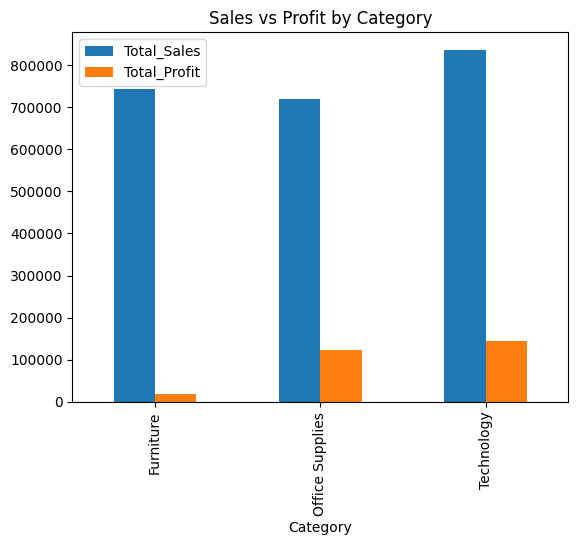

In [13]:
import matplotlib.pyplot as plt

category_view.plot(x="Category", y=["Total_Sales","Total_Profit"], kind="bar")
plt.title("Sales vs Profit by Category")
plt.show()

## Customer Cluster Visualization 

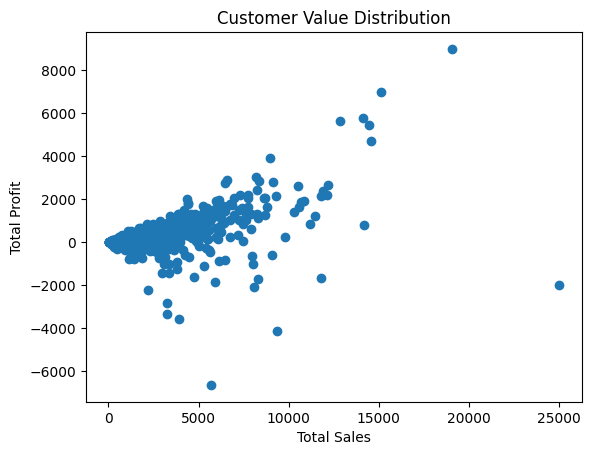

In [14]:
plt.scatter(customer_view["Total_Sales"], customer_view["Total_Profit"])
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.title("Customer Value Distribution")
plt.show()

## Conclusion 

The business generates strong sales, but profit is inconsistent across customers, products, and categories. A small group of customers and products drives most of the profit, while others reduce margins due to high discounts or poor pricing. Focusing on high-value segments and optimizing pricing strategies will significantly improve overall profitability.